# 11 - Is the Screener Useful, and Is the Ceiling Real? (Albania 2022)

Two pre-submission strengthenings that answer the two hardest questions a reviewer asks about a ~0.78-AUC model on a **75%-prevalence** problem:

1. **Does the model add decision value** over the trivial 'screen everyone' / 'screen no-one' policies, and are its probabilities trustworthy? → **decision-curve analysis + calibration** (`scripts/run_decision_curve.py`).
2. **Is the 0.78 ceiling a modelling shortfall or a property of the data?** → a **multilevel (random-intercept) logistic model**, the statistically-correct spec for PISA's nested design, which also quantifies how much risk is a *school-level* phenomenon (`scripts/run_multilevel.py`).

Both scripts do the heavy fitting (leakage-safe, OpenMP-isolated); this notebook loads their results and redraws the figures.

## Methods & formulas (reference)

Two pre-submission strengthenings: an evaluation fit for a high-prevalence
*screener*, and the statistically-correct model for PISA's nested design.

**Decision-curve analysis (net benefit).** At a threshold probability $p_t$ we flag
a student when $\hat p \ge p_t$; $p_t$ encodes the harm trade-off (a false alarm
costs $p_t/(1-p_t)$ times as much as a miss). The weighted net benefit is
$$\mathrm{NB}(p_t)=\frac{TP_w}{N_w}-\frac{FP_w}{N_w}\,\frac{p_t}{1-p_t},$$
compared against **screen-everyone** ($\mathrm{NB}=\mathrm{prev}-(1-\mathrm{prev})\,
p_t/(1-p_t)$) and **screen-no-one** ($\mathrm{NB}=0$). The model earns its keep only
where its curve sits above both.

**Calibration.** Weighted **Brier** $\frac{\sum_i w_i(\hat p_i-y_i)^2}{\sum_i w_i}$
and **ECE** $\sum_b \frac{w_b}{W}\lvert \mathrm{obs}_b-\overline{\hat p}_b\rvert$ over
probability bins; a reliability curve plots observed vs predicted. Isotonic
regression is a monotone recalibration map fit out-of-fold.

**Random-intercept (multilevel) logistic.** Students $i$ nested in schools $j$:
$$\operatorname{logit}P(y_{ij}=1)=\beta_0+\beta^\top x_{ij}+u_j,\qquad
u_j\sim\mathcal N(0,\sigma_u^2).$$
The **intraclass correlation** on the latent scale,
$$\mathrm{ICC}=\frac{\sigma_u^2}{\sigma_u^2+\pi^2/3},\qquad \pi^2/3\approx3.29,$$
is the share of risk variance that is *between schools*. Fixed effects give
*within-school* odds ratios $e^{\beta}$ (per 1 SD). Fit by variational Bayes;
unweighted (no survey weights in the mixed GLM) - a noted caveat.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

## Part A - Decision-curve analysis: does acting on the model help?

With ~3 in 4 students at-risk, ROC-AUC is mechanically capped and says little about *use*. Net benefit asks the operational question directly: at a given risk tolerance $p_t$, does flagging students the model picks beat flagging everyone (or no-one)?

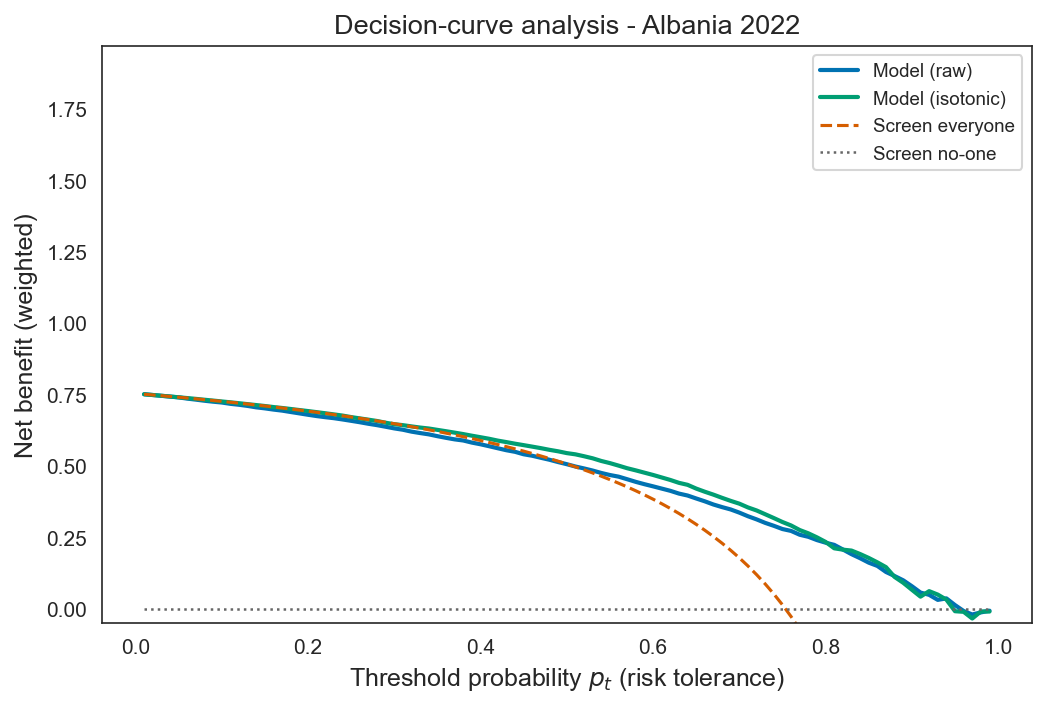

Model beats both references over p_t 0.51-0.95


In [2]:
dca = pd.read_csv('../outputs/results/decision_curve_2022.csv')
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(dca.threshold, dca.net_benefit_model, color=PALETTE['blue'], lw=2, label='Model (raw)')
ax.plot(dca.threshold, dca.net_benefit_model_calibrated, color=PALETTE['green'], lw=2, label='Model (isotonic)')
ax.plot(dca.threshold, dca.net_benefit_all, color=PALETTE['vermilion'], lw=1.5, ls='--', label='Screen everyone')
ax.plot(dca.threshold, dca.net_benefit_none, color='0.4', lw=1.2, ls=':', label='Screen no-one')
ax.set_ylim(bottom=min(-0.05, dca.net_benefit_model.min()))
ax.set_xlabel('Threshold probability $p_t$ (risk tolerance)'); ax.set_ylabel('Net benefit (weighted)')
ax.set_title('Decision-curve analysis - Albania 2022'); ax.legend(fontsize=9); plt.show()
better = dca[(dca.net_benefit_model>dca.net_benefit_all)&(dca.net_benefit_model>0)]
print(f'Model beats both references over p_t {better.threshold.min():.2f}-{better.threshold.max():.2f}')

**Reading:** below the prevalence (~0.75) 'screen everyone' is hard to beat - when most students are at-risk, indiscriminate screening is already good. The model earns its keep in the **selective regime** (higher $p_t$, ~0.51–0.95), where it holds net benefit while 'screen everyone' collapses below zero. A triage tool that must ration scarce support - the realistic case - operates exactly there.

## Part B - Calibration: do the probabilities mean what they say?

Raw boosted-tree scores are typically miscalibrated; a weighted isotonic map (fit out-of-fold) fixes them. This matters because the decision threshold $p_t$ above is only meaningful if $\hat p$ is a real probability.

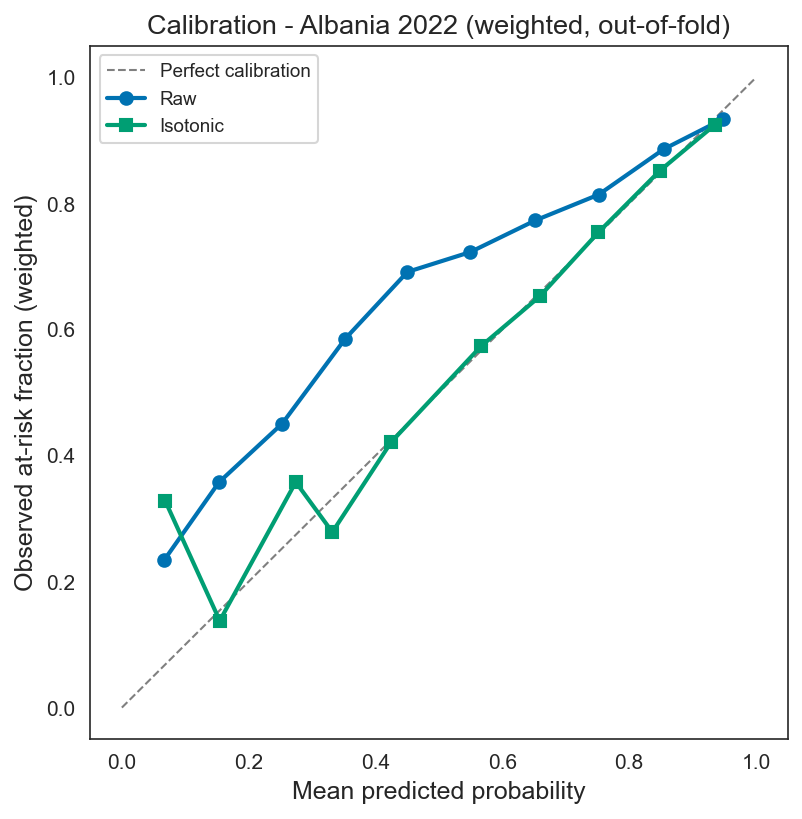

In [3]:
raw = pd.read_csv('../outputs/results/calibration_raw_2022.csv')
iso = pd.read_csv('../outputs/results/calibration_isotonic_2022.csv')
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1], color='0.5', ls='--', lw=1, label='Perfect calibration')
ax.plot(raw.mean_predicted, raw.observed_fraction, '-o', color=PALETTE['blue'], lw=2, label='Raw')
ax.plot(iso.mean_predicted, iso.observed_fraction, '-s', color=PALETTE['green'], lw=2, label='Isotonic')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed at-risk fraction (weighted)')
ax.set_title('Calibration - Albania 2022 (weighted, out-of-fold)'); ax.legend(fontsize=9, loc='upper left'); plt.show()

**Reading:** the raw model is over-confident (bows above the diagonal); isotonic recalibration lands it on the diagonal - weighted **ECE ~0.10 → ~0.01**. Calibrated probabilities are what make the decision-curve thresholds actionable.

## Part C - Multilevel model: how much risk is a *school* effect?

A flat logistic treats students as independent; they are not - they are nested in schools. A random-intercept model gives each school its own baseline log-odds $u_j$ and reports the **ICC**: the share of risk variance that lives *between* schools.

In [4]:
summ = pd.read_csv('../outputs/results/multilevel_summary_2022.csv').iloc[0]
cv = pd.read_csv('../outputs/results/multilevel_cv_2022.csv')
print(f"ICC (null)        = {summ.icc_null:.3f}  -> ~{summ.icc_null*100:.0f}% of risk variance is BETWEEN schools")
print(f"ICC (conditional) = {summ.icc_conditional:.3f}  (student features barely reduce it)")
print(f"ICC (weighted PQL)= {summ.icc_weighted_pql:.3f}  (survey-weighted pseudo-likelihood, scaled wts; PQL mildly attenuates)")
print(f"\nCV mean AUC: multilevel {summ.auc_multilevel_mean:.4f} vs school-mean LightGBM {summ.auc_school_lgbm_mean:.4f}")
cv.round(4)

ICC (null)        = 0.308  -> ~31% of risk variance is BETWEEN schools
ICC (conditional) = 0.257  (student features barely reduce it)
ICC (weighted PQL)= 0.220  (survey-weighted pseudo-likelihood, scaled wts; PQL mildly attenuates)

CV mean AUC: multilevel 0.7830 vs school-mean LightGBM 0.7728


,fold,auc_multilevel,auc_school_lgbm
0,1,0.8041,0.7858
1,2,0.7621,0.7370
2,3,0.7858,0.7776
3,4,0.7667,0.7584
4,5,0.7965,0.8053


**Survey-weighted refinement.** The VB fit above ignores PISA sampling weights. A survey-weighted **pseudo-likelihood** fit (penalized quasi-likelihood, Schall 1991, with within-cluster scaled weights - Rabe-Hesketh & Skrondal) gives design-consistent fixed effects. The two agree closely, so the weighting does **not** change the story (it only sharpens it) - the odds ratios below are near-identical weighted vs unweighted.

In [5]:
orc = pd.read_csv('../outputs/results/multilevel_weighted_vs_unweighted_2022.csv')
orc = orc[orc.term!='Intercept'][['term','OR_unweighted_vb','OR_weighted_pql']]
print('Max |OR_weighted - OR_unweighted| =', (orc.OR_weighted_pql-orc.OR_unweighted_vb).abs().max().round(3))
orc.round(3)

Max |OR_weighted - OR_unweighted| = 0.024


,term,OR_unweighted_vb,OR_weighted_pql
1,ESCS,0.861,0.869
2,HOMEPOS,0.799,0.807
3,GENDER,1.129,1.124
4,REPEAT,1.215,1.198
5,IMMIG,1.043,1.035
6,BELONG,0.922,0.925
7,TEACHSUP,0.908,0.908
8,ICTHOME,1.016,1.020
9,ICTSCH,1.057,1.054
10,ANXMAT,1.462,1.438


**Within-school odds ratios** (per 1 SD). Risk-increasing factors in vermilion, protective in blue; the school baseline is absorbed by the random intercept.

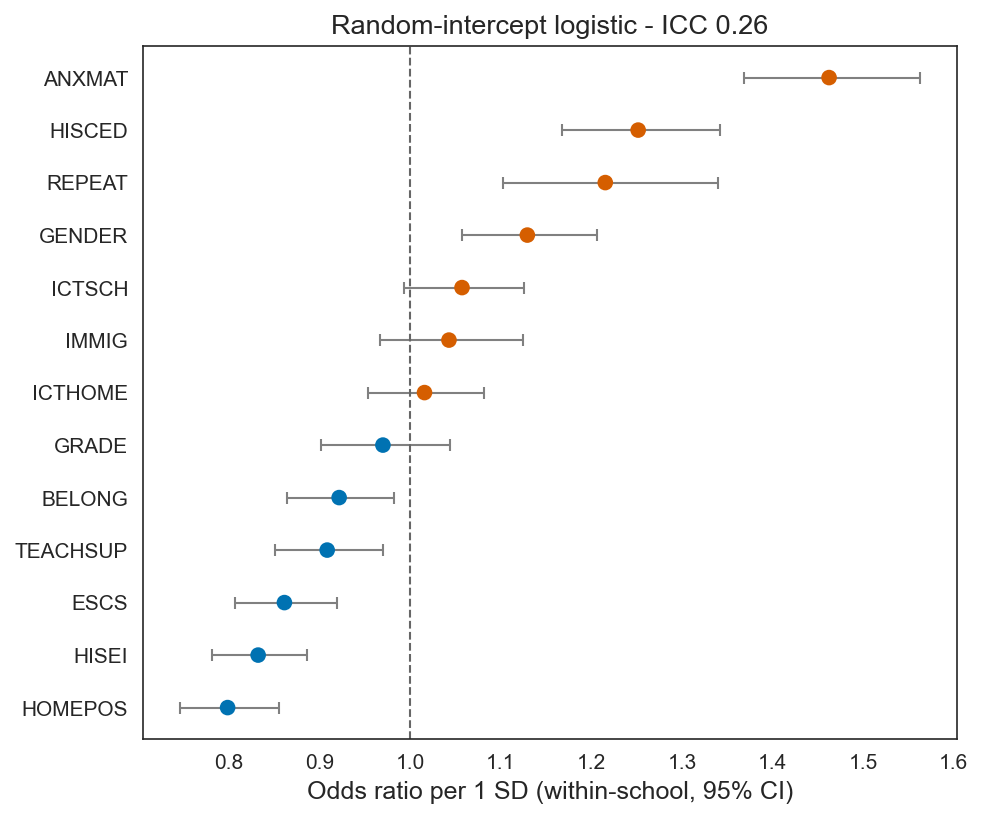

In [6]:
fe = pd.read_csv('../outputs/results/multilevel_fixed_effects_2022.csv')
fe = fe[fe.term!='Intercept'].copy()
fe['lo']=np.exp(fe.coef-1.96*fe.sd); fe['hi']=np.exp(fe.coef+1.96*fe.sd)
fe = fe.sort_values('odds_ratio'); yp=np.arange(len(fe))
colors=[PALETTE['vermilion'] if o>1 else PALETTE['blue'] for o in fe.odds_ratio]
fig, ax = plt.subplots(figsize=(7,6))
ax.errorbar(fe.odds_ratio, yp, xerr=[fe.odds_ratio-fe.lo, fe.hi-fe.odds_ratio], fmt='none', ecolor='0.5', elinewidth=1, capsize=3, zorder=1)
ax.scatter(fe.odds_ratio, yp, color=colors, s=42, zorder=2)
ax.axvline(1.0, color='0.4', ls='--', lw=1)
ax.set_yticks(yp); ax.set_yticklabels(fe.term)
ax.set_xlabel('Odds ratio per 1 SD (within-school, 95% CI)')
ax.set_title(f"Random-intercept logistic - ICC {summ.icc_conditional:.2f}"); plt.show()

**Reading:** math anxiety (`ANXMAT`) is the strongest within-school risk factor; the SES cluster (`HOMEPOS`, `HISEI`, `ESCS`) is protective. `HISCED` flips positive - a *partial* effect under SES collinearity (the composite SES protection is already carried by HOMEPOS/HISEI/ESCS), not a real reversal; read the SES measures jointly.

## Conclusions & Interpretation

- **The model has genuine decision value - in the selective regime.** Net benefit beats both 'screen everyone' and 'screen no-one' for risk thresholds ~0.51–0.95. For a triage tool rationing scarce support that is the operating range that matters; the modest AUC is the wrong lens.
- **Calibration is essentially fixed.** Weighted isotonic recalibration cuts ECE from ~0.10 to ~0.01, making the probabilities (and hence the thresholds) trustworthy.
- **The 0.78 ceiling is real, not a modelling shortfall.** The statistically-correct multilevel model - student features + a data-driven school random effect - matches the hand-crafted school-mean booster on identical folds (CV AUC ~0.78 either way). Two independent model families converge on the same ceiling.
- **~31% of risk variance is between schools** (null ICC), barely reduced by student features (conditional ICC ~0.26). Risk is heavily a *school-level* phenomenon that student background cannot explain away - which motivated linking **school-level information** (the PISA school questionnaire: resources, staff, leadership). **Notebook 12 does that linkage and finds it adds no significant predictive signal** beyond school composition - so this ~0.78 ceiling is a genuine data limit, not an un-linked-file artefact.
- **Survey weighting does not change the conclusions.** Beyond the unweighted VB fit, a survey-weighted pseudo-likelihood model (PQL with within-cluster scaled weights) gives design-consistent fixed effects; the odds ratios are near-identical (max shift ~0.05) and the ICC lands in the same 0.22-0.31 band. The variance-partition and within-school risk story is robust to how sampling weights are handled.